In [ ]:
# Objective: Validate correlation of Fuel_Consumption_Comb_L_per_100_km, Engine_Size_L, cilinders, Fuel_Type and Vehicle_Type


import pandas as pd

df = pd.read_csv('../data/raw/co2.csv')


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import joblib
from sklearn.metrics import mean_absolute_error, r2_score

df = df.rename(columns={
    'Vehicle Class': 'Vehicle_type',
    'Engine Size(L)': 'Engine_Size_L',
    'Fuel Type': 'Fuel_Type',
    'Fuel Consumption Comb (L/100 km)': 'Fuel_Consumption_Comb_L_per_100_km',
    'CO2 Emissions(g/km)': 'CO2_Emissions_g_per_km'
})


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

direct_correlation = df['CO2_Emissions_g_per_km'].corr(df['Fuel_Consumption_Comb_L_per_100_km'])
print(f"Direct Correlation: {direct_correlation:.4f}")

Direct Correlation: 0.9181


In [5]:
correlation_matrix = df.corr(numeric_only=True)

In [6]:
correlation_if_co2 = correlation_matrix['CO2_Emissions_g_per_km'].sort_values(ascending=False)
print(f"\nCorrelation of var if CO2 emissions: {correlation_if_co2}")


Correlation of var if CO2 emissions: CO2_Emissions_g_per_km                1.000000
Fuel Consumption City (L/100 km)      0.919592
Fuel_Consumption_Comb_L_per_100_km    0.918052
Fuel Consumption Hwy (L/100 km)       0.883536
Engine_Size_L                         0.851145
Cylinders                             0.832644
Fuel Consumption Comb (mpg)          -0.907426
Name: CO2_Emissions_g_per_km, dtype: float64


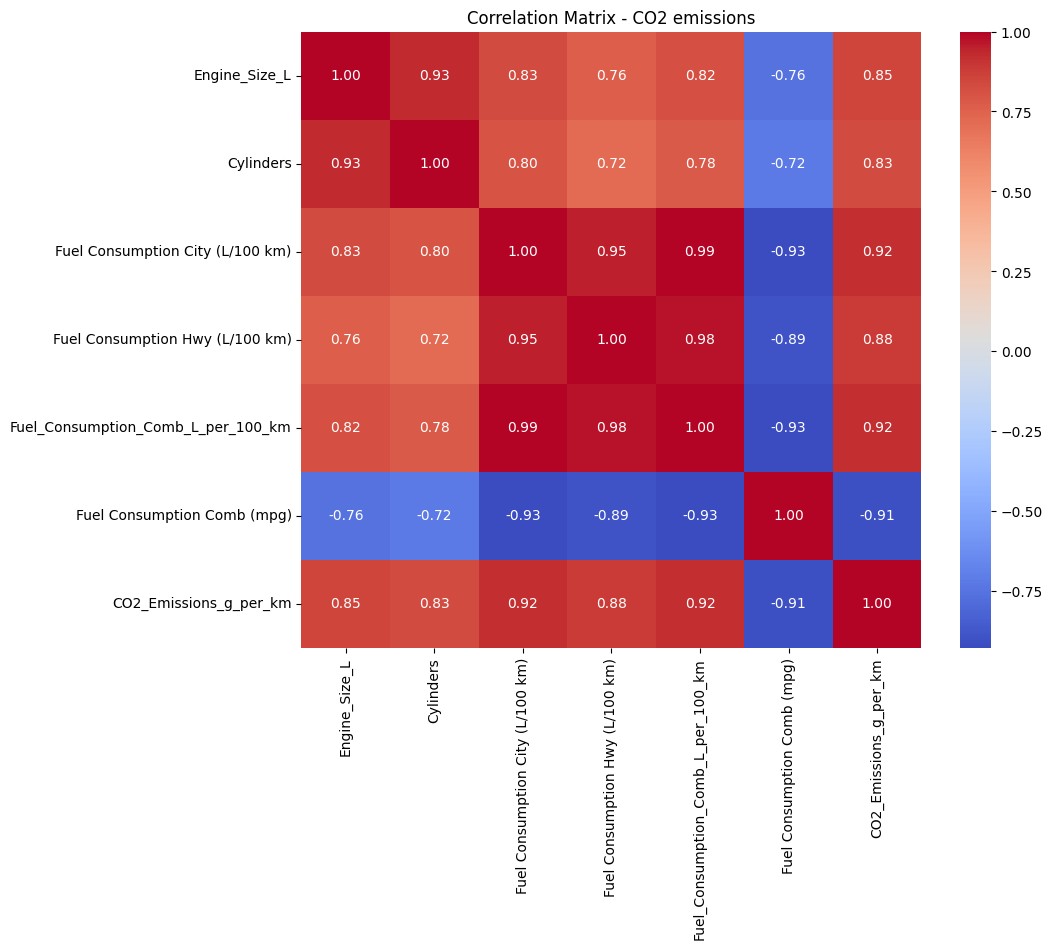

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - CO2 emissions")
plt.show()